# 1. Install Dependencies

In [1]:
# Core Python and deep learning libraries
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim

# Computer vision utilities and image preprocessing tools
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# Numerical computation and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Evaluation metrics
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Import EfficientNet-B0 architecture
from torchvision.models import efficientnet_b0

# Configure GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete. Operating on device: {device}")

Setup complete. Operating on device: cuda


# 2. Dataset Preparation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Define the path to val_idx and test_idx files in Google Drive
val_idx_path = '/content/drive/MyDrive/DeepLearning/val_idx.zip'
test_idx_path = '/content/drive/MyDrive/DeepLearning/test_idx.zip'
baseline_model_path = '/content/drive/MyDrive/DeepLearning/Baseline_model.zip'

Mounted at /content/drive


### 2.1 Data Preprocessing

To prepare the images for training, we'll apply a series of transformations. These transformations ensure that all images are of a consistent size, normalized, and augmented to improve model generalization.

**Transformations:**
-   `Resize(256)`: Resizes the shortest side of the image to 256 pixels while maintaining the aspect ratio.
-   `CenterCrop(224)`: Crops the image to a square of size 224x224 pixels from the center.
-   `ToTensor()`: Converts the image to a PyTorch tensor.
-   `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`: Normalizes the image pixel values using pre-defined mean and standard deviation values, which are typical for models pre-trained on ImageNet.

In [3]:
# Define transformations for the training, validation, and test sets
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 2.2 Dataset Loading and Splitting

The dataset is loaded using the built in `EuroSAT`class from `torchvision.dataset`. During this phase we apply transfer learning and only use the validation set (from the basline phase). The validation set is split into training, and validation sets with an 80:20 ratio.

-   **Seed for Reproducibility**: A random seed is set to ensure that the dataset split is reproducible.
-   **`train_test_split`**: Used to divide the dataset indices into training and validation sets. The `stratify` parameter ensures that the class distribution is maintained across splits.
-   **`Subset`**: Creates actual dataset subsets based on the generated indices.

In [4]:
# Load EuroSAT Dataset
raw_dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transforms.ToTensor())

# Loading dataset with ImageNet-standard transformations
dataset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

# Get class names
class_names = dataset.classes
print(f"Found {len(class_names)} classes: {class_names}")

# Load predefined baseline splits (validation and test indices )
baseline_val_idx = torch.load(val_idx_path, map_location='cpu')
baseline_test_idx = torch.load(test_idx_path, map_location='cpu')

# Re-purpose baseline validation set as the working dataset
# and perform a stratified split (80% training, 20% validation)
# to enable proper early stopping and model selection
val_targets = [dataset.targets[i] for i in baseline_val_idx]

train_idx, val_idx = train_test_split(
    baseline_val_idx,
    test_size=0.20,
    random_state=42,
    stratify=val_targets
)

# Create subsets for train, validation, and test
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, baseline_test_idx)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 171MB/s]


Found 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train dataset size: 2160
Validation dataset size: 540
Test dataset size: 2700


### 2.3 DataLoader Creation

DataLoaders are essential for efficient batch processing of image data during training and evaluation. They handle shuffling, batching, and loading data in parallel.

-   **`batch_size`**: The number of samples processed in each iteration. A batch size of 32 is a common choice.
-   **`shuffle=True`**: For the training DataLoader, shuffling the data in each epoch helps improve model generalization and prevents the model from learning the order of the training examples.
-   **`num_workers`**: Specifies the number of subprocesses to use for data loading. This can speed up data fetching, especially when transformations are complex. Setting it to 2 is a good starting point.
-   **`pin_memory=True`**: This can speed up data transfer to GPU by pre-pinning memory. It's useful when training on GPU.

These DataLoaders will be used in the training loop to feed data to the model in mini-batches.

In [5]:
# Define batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


# 3. Baseline Model Initialization
---

In [6]:
# Instantiate backbone architecture and adjust output features for EuroSAT (10 classes)
baseline_model = efficientnet_b0(weights=None)
baseline_model.classifier[1] = nn.Linear(baseline_model.classifier[1].in_features, 10)

# Load pretrained baseline model weights
baseline_model.load_state_dict(torch.load(baseline_model_path, map_location=device))
baseline_model = baseline_model.to(device)

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, mode= 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_value = None
        self.early_stop = False
        self.mode = mode

    def __call__(self, value):
        if self.best_value is None:
            self.best_value = value
        elif self._is_worse(value):
            self.counter += 1
            print(f"   [EarlyStopping Update] No improvement counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_value = value
            self.counter = 0

    def _is_worse(self, value):
        if self.mode == 'min':
            return value > self.best_value - self.min_delta
        else:
            return value < self.best_value + self.min_delta

# Training loop for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return (running_loss / len(dataloader)), (100 * correct / total)

# Validation loop for one epoch
def validate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return (running_loss / len(dataloader)), (100.0 * correct / total)

 # Evaluate model performance and plot confusion matrix
def evaluate_and_plot_matrix(model, dataloader, opt_name):
    model.eval()
    all_preds, all_labels = [], []
    correct_5 = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Calculate Top-5 accuracy
            _, top5 = outputs.topk(5, 1, True, True)
            correct_5 += sum([labels[i] in top5[i] for i in range(labels.size(0))])

    # Calculate performance metrics
    top1 = 100 * (np.array(all_preds) == np.array(all_labels)).mean()
    top5 = 100 * correct_5 / len(dataloader.dataset)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    print("\n" + "="*50)
    print(f"METRICS REPORT: {opt_name}")
    print(f"Top-1 Accuracy: {top1:.2f}% | Top-5 Accuracy: {top5:.2f}%")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f}")
    print("="*50 + "\n")

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {opt_name}')
    plt.xlabel('Predicted Class Labels')
    plt.ylabel('Actual Ground Truth Labels')
    plt.show()

print("Shared metrics and functional pipelines ready.")

Shared metrics and functional pipelines ready.


In [7]:
# Iterate through the feature extractor to understand the architectural structure of the backbone
for i, layer in enumerate(baseline_model.features):
    print(f"Layer {i}: {type(layer).__name__}")

# Iterate through the classifier head components to understand the final classification layers
for i, layer in enumerate(baseline_model.classifier):
    print(f"Layer {i}: {type(layer).__name__}")

Layer 0: Conv2dNormActivation
Layer 1: Sequential
Layer 2: Sequential
Layer 3: Sequential
Layer 4: Sequential
Layer 5: Sequential
Layer 6: Sequential
Layer 7: Sequential
Layer 8: Conv2dNormActivation
Layer 0: Dropout
Layer 1: Linear


# 4. Model Final Improvement

### 1. Experimental Results Tables:



#### 1.1.1. Optimizer Performance Analysis


| Experiment | LR / Strategy | Top-1 Accuracy | Top-5 Accuracy | Precision | Recall |
| :--- | :--- | :--- | :--- | :--- | :--- |
| SGD + Momentum | 0.1 (Baseline) | 88.85% |99.78% | 0.8923 | 0.8834 |  
| SGD + Momentum | 0.001 | 92.48% | 99.78% | 0.9246 | 0.9202 |
| RMSprop | 0.1 (Baseline) | 86.30% | 99.37% | 0.8702 |  0.8503 |
| RMSprop | 0.001 | 92.52% | 99.81% | 0.9237 | 0.9212 |
| Adam | 0.1 (Baseline) | 86.96% | 99.63% | 0.8741 | 0.8617 |
| Adam | 0.001 | 92.41% | 99.96% | 0.9236 | 0.9198 |



#### 1.2.1. Regularization Performance Analysis

| Experiment | Parameter Value | Top-1 Accuracy | Top-5 Accuracy | Precision | Recall |
| :--- | :--- | :---: | :--- | :--- | :--- |
| Dropout | 0.2 | 92.26% | 99.89% | 0.9233 | 0.9182 |
| Dropout | 0.4 | 91.81% | 99.85% | 0.9190 | 0.9124 |
| Weight Decay | 1e-4 | 92.30% | 99.93% | 0.9207 | 0.9200 |  

#### 1.3.1 Fine-Tuning Performance Analysis

| Experiment | LR / Strategy | Top-1 Accuracy | Top-5 Accuracy | Precision | Recall |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Unfreezing 2 Layers | 0.1 (Baseline) | 94.00% | 99.93% | 0.9409 | 0.9367 |
| Unfreezing 2 Layers + Discriminative LR | D-LR Setting | 92.96% | 99.96% | 0.9288 |  0.9258 |
| Unfreezing 2 Layers + LR Scheduler | ReduceLROnPlateau | 94.63%  | 99.96% |  0.9457 | 0.9438 |




### 2. Summary of the chosen Best Experimental Results

| Category | Best Configuration |
| :--- | :--- |
| Optimizer | SGD + Momentum |
| Regularization |Weight Decay |
| Fine-tuning | Unfreezing 2 Layers + LR Scheduler |

---

In [12]:
# Importing ReduceLROnPlateau for Learning Rates Sceduling
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Importing ReduceLROnPlateau for Learning Rates Sceduling
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Setup: Create a copy of the baseline model
final_model = copy.deepcopy(baseline_model)
final_model = final_model.to(device)

# --- Improvement 1: Unfreezing 2 Layers + LR Scheduler ---
# Define which parts of the model are trainable. We freeze the entire backbone initially
# to preserve learned features, then selectively enable gradients for specific layers.
# Below we will configure the Learning Rate Scheduler to monitor validation accuracy

# Freeze all parameters first
for param in final_model.parameters():
    param.requires_grad = False

# Unfreeze the classifier
for param in final_model.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 2 blocks of the backbone (features)
for block in final_model.features[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Training Configuration

# --- Improvement 2 & 3: Initialize Optimizer with Weight Decay Regularization ---
# Use a filter to update ONLY the parameters with requires_grad=True.
# We use 1e-4 as a standard regularization value to penalize large weights
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, final_model.parameters()),
    momentum=0.9,
    weight_decay=1e-4,
    lr=0.1)

# Configure the Learning Rate Scheduler to monitor validation accuracy
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)
criterion = nn.CrossEntropyLoss()
early_stopping = EarlyStopping(patience=5, mode='max')
trial_history = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
    }

# Training Loop
num_epochs = 100
best_val_acc = 0.0
best_model_state = None

print("\n" + "=" * 60)
print(f"Final model Experiment:")
print("=" * 60)

for epoch in range(num_epochs):
    # Training
    train_loss, train_acc = train_one_epoch(
        final_model, train_loader, criterion, optimizer
    )

    # Validation
    val_loss, val_acc = validate(
        final_model, val_loader, criterion
        )

    # Update learning rate based on validation performance (Plateau detection)⁠
    scheduler.step(val_acc)

    # Save history for plotting
    trial_history['train_acc'].append(train_acc)
    trial_history['val_acc'].append(val_acc)
    trial_history['train_loss'].append(train_loss)
    trial_history['val_loss'].append(val_loss)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(final_model.state_dict())
        print(" ✓ Best!", end="")

    print()

    # Early Stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nOptimization Finished. Best Accuracy: {best_val_acc:.2f}%")


Final model Experiment:
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 1.2403 | Train Acc: 77.45% | Val Loss: 1.1587 | Val Acc: 82.96% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 0.5980 | Train Acc: 86.85% | Val Loss: 0.4358 | Val Acc: 89.81% ✓ Best!
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 0.2316 | Train Acc: 92.87% | Val Loss: 0.2964 | Val Acc: 91.48% ✓ Best!
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 0.1982 | Train Acc: 94.31% | Val Loss: 0.3636 | Val Acc: 91.48%
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 0.1524 | Train Acc: 95.19% | Val Loss: 0.4081 | Val Acc: 90.19%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 0.0924 | Train Acc: 97.13% | Val Loss: 0.4003 | Val Acc: 92.41% ✓ Best!
Epoch [ 7/100] | LR: 0.100000 | Train Loss: 0.0812 | Train Acc: 97.22% | Val Loss: 0.3284 | Val Acc: 91.11%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 8/100] | LR: 0.100000 | Train Loss: 0.0755 | Train Acc: 9

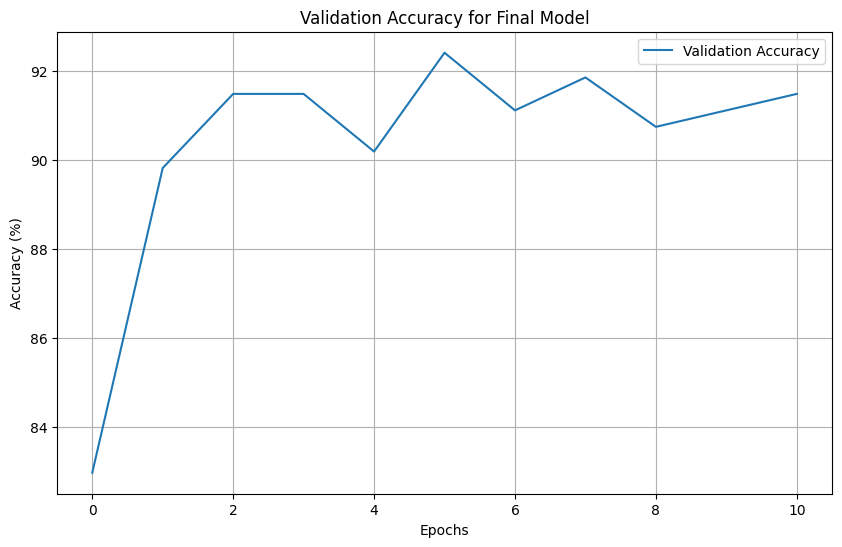

In [13]:
# Performance Visualization
plt.figure(figsize=(10, 6))
plt.plot(trial_history['val_acc'], label='Validation Accuracy')
plt.title('Validation Accuracy for Final Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


METRICS REPORT: Final Model
Top-1 Accuracy: 94.74% | Top-5 Accuracy: 99.85%
Precision: 0.9479 | Recall: 0.9434



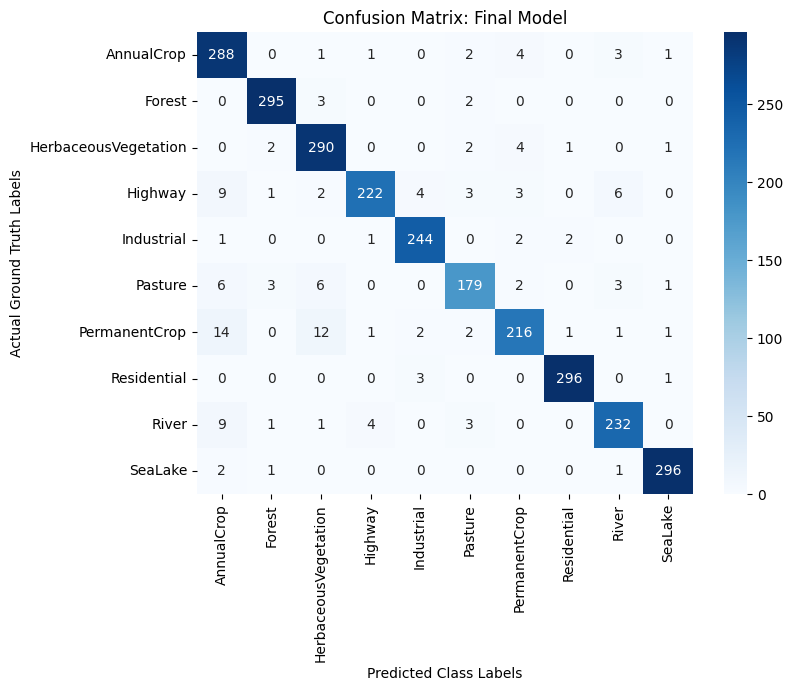

In [14]:
# Final Evaluation: Test Set + Confusion Matrix
# Loading Best Model Weights
if best_model_state is not None:
    final_model.load_state_dict(best_model_state)

# Evaluating
evaluate_and_plot_matrix(
    final_model,
    test_loader,
    "Final Model"
    )